In [1]:
from IPython.display import IFrame
%matplotlib inline
import matplotlib.pyplot as plt
import getpass
import xarray as xr
import panel.widgets as pnw
import panel as pn
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import copernicusmarine
import hvplot.xarray
import hvplot.pandas
# To avoid warning messages
import warnings
warnings.filterwarnings('ignore')

/opt/anaconda3/envs/copernicusmarine/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
sst = copernicusmarine.open_dataset(dataset_id = 'METOFFICE-GLO-SST-L4-REP-OBS-SST')
sst

INFO - 2025-07-26T13:00:07Z - Selected dataset version: "202003"
INFO - 2025-07-26T13:00:07Z - Selected dataset part: "default"


<xarray.Dataset> Size: 11TB
Dimensions:           (time: 14853, latitude: 3600, longitude: 7200)
Coordinates:
  * latitude          (latitude) float32 14kB -89.97 -89.93 ... 89.93 89.97
  * longitude         (longitude) float32 29kB -180.0 -179.9 ... 179.9 180.0
  * time              (time) datetime64[ns] 119kB 1981-10-01 ... 2022-05-31
Data variables:
    analysed_sst      (time, latitude, longitude) float64 3TB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    analysis_error    (time, latitude, longitude) float64 3TB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    mask              (time, latitude, longitude) float32 2TB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    sea_ice_fraction  (time, latitude, longitude) float64 3TB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
Attributes:
    source:       AMSR2-REMSS-L2P-v2.0, AMSRE-REMSS-L2P-v2.0, GOES<13,16>-OSI...
    Conventions:  CF-1.4, ACDD-1.3
    title:        Global SST & Sea Ice Analysis, L4 OSTIA, 0.05 deg daily (ME...
    references:   Donlon, C.J., Martin, M., Stark, J.D., Roberts-Jones, J., F...
    history:      Created from sst.nc; obs_anal.nc; seaice.nc
    institution:  UKMO
    comment:      WARNING Some applications are unable to properly handle sig...

In [25]:
# Define the two longitude regions
lon_west = slice(140, 180)
lon_east = slice(-180, -130)
latitude = slice(-25, 15)

# Extract data for both regions
sst_west = sst['analysed_sst'].sel(latitude=latitude, longitude=lon_west)
sst_east = sst['analysed_sst'].sel(latitude=latitude, longitude=lon_east)

# Concatenate along longitude dimension
sst_combined = xr.concat([sst_west, sst_east], dim='longitude')

# Calculate spatial average
average_sst = sst_combined.mean(dim=['latitude', 'longitude'])

# Calculate annual averages and convert to Celsius
annual_avg_sst = average_sst.resample(time='1Y').mean()
annual_sst_celsius = annual_avg_sst - 273.15


In [27]:
annual_sst_celsius.to_dataframe().to_csv('total_average_sst.csv')


In [28]:
import pandas as pd
annual_sst_celsius_df=pd.read_csv('total_average_sst.csv')

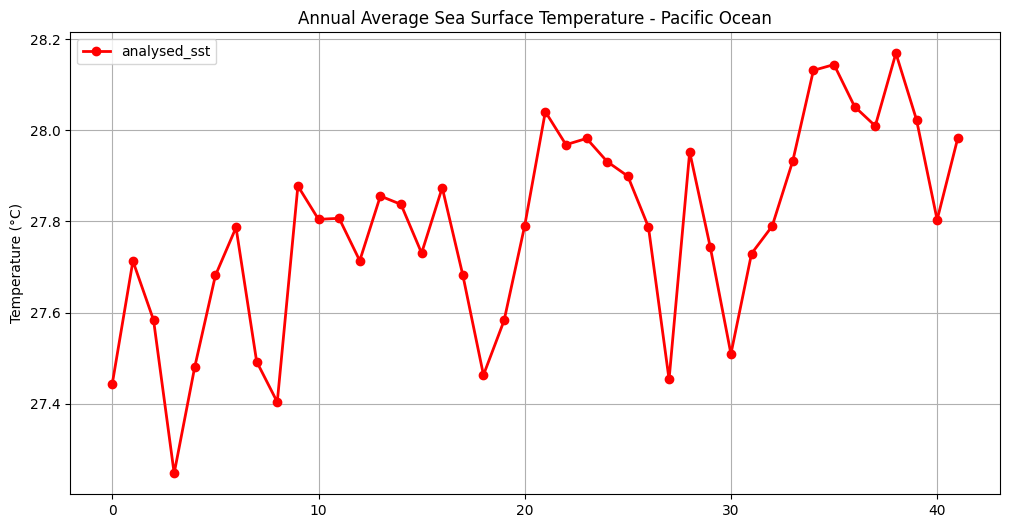

In [29]:
annual_sst_celsius_df.plot(figsize=(12, 6), marker='o', linewidth=2, color='red')
plt.title('Annual Average Sea Surface Temperature - Pacific Ocean')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()